In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings,itertools
from scipy import stats
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression
import os

os.makedirs("Graphs", exist_ok=True)
_original_show = plt.show
plt.show = lambda *args, **kwargs: (plt.savefig(f"Graphs/{plt.gca().get_title() or f'Figure_{plt.gcf().number}'}.png", dpi=150, bbox_inches="tight"), _original_show(*args, **kwargs))


fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

maxcols=3
cellwidth=5
cellheight=4
singlesize=(8,5)
topn=6

def setGraphStyle():
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150
    sns.set_style('whitegrid')

def gridAxes(n):
    ncols=min(maxcols,n)
    nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(cellwidth*ncols,cellheight*nrows))
    axes=np.array(axes).reshape(-1)
    return fig,axes

def showFig(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)

def datasetOverview(df):
    rows,cols=df.shape
    names=df.columns.tolist()
    types=df.dtypes.astype(str).tolist()
    return rows,cols,names,types

def checkMissing(df):
    miss=df.isnull().sum()
    dup=df.duplicated().sum()
    single=[c for c in df.columns if df[c].nunique()==1]
    empty=[c for c in df.columns if df[c].isnull().all()]
    mixed=[]
    obj=df.select_dtypes(include=['object','string']).columns
    for c in obj:
        if c in empty:
            continue
        s=df[c].dropna().astype(str)
        if s.empty:
            continue
        if s.str.match(r'^-?\d+(\.\d+)?$').all():
            mixed.append(c)
    return miss,dup,single,empty,mixed

def analyzeNumeric(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    summary=num.describe().T
    summary=summary.rename(columns={'mean':'Mean','std':'Std','min':'Min','max':'Max','50%':'Median','25%':'Q1','75%':'Q3'})
    summary['Mode']=num.mode().iloc[0]
    summary['Range']=summary['Max']-summary['Min']
    summary['Skewness']=num.skew()
    summary['Kurtosis']=num.kurt()
    cols=['Mean','Median','Mode','Std','Min','Max','Q1','Q3','Range','Skewness','Kurtosis']
    return summary[cols]

def analyzeCategorical(df):
    cat=df.select_dtypes(include=['object','string','category'])
    if cat.empty:
        return None
    data=[]
    for c in cat.columns:
        unique=cat[c].nunique()
        mode=cat[c].mode()
        top=mode.iloc[0] if not mode.empty else None
        freq=cat[c].value_counts().iloc[0] if not cat[c].value_counts().empty else 0
        data.append([c,unique,top,freq])
    return pd.DataFrame(data,columns=['Column','Unique','Top Value','Frequency'])

def analyzeNormality(df,alpha=0.05):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    rows=[]
    for c in num.columns:
        data=num[c].dropna()
        if len(data)<3:
            continue
        sample=data.sample(min(len(data),5000),random_state=42)
        statval,p=stats.shapiro(sample)
        rows.append([c,statval,p,'Normal' if p>alpha else 'Not Normal'])
    return pd.DataFrame(rows,columns=['Column','Statistic','P-Value','Result'])

def mutualInfoAnalysis(df,target):
    if target not in df.columns:
        return None
    num=df.select_dtypes(include=['number']).drop(columns=[target],errors='ignore')
    if num.empty:
        return None
    X=num.fillna(num.median())
    y=df[target]
    if y.dtype=='object' or str(y.dtype)=='category' or y.nunique()<20:
        yenc=y.astype('category').cat.codes
        mi=mutual_info_classif(X,yenc,random_state=42)
    else:
        mi=mutual_info_regression(X,y,random_state=42)
    return pd.DataFrame({'Feature':num.columns,'Mutual Information':mi}).sort_values('Mutual Information',ascending=False).reset_index(drop=True)

def detectOutliers(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    data=[]
    for c in num.columns:
        q1=num[c].quantile(0.25)
        q3=num[c].quantile(0.75)
        iqr=q3-q1
        low=q1-1.5*iqr
        high=q3+1.5*iqr
        count=((num[c]<low)|(num[c]>high)).sum()
        data.append([c,count])
    return pd.DataFrame(data,columns=['Column','Outlier Count'])

def correlationAnalysis(df):
    num=df.select_dtypes(include=['number'])
    return num.corr() if not num.empty else None

def highCorrFeatures(df,limit=0.8):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    corr=num.corr().abs()
    pairs=[]
    for i in range(len(corr.columns)):
        for j in range(i+1,len(corr.columns)):
            val=corr.iloc[i,j]
            if val>=limit:
                pairs.append([corr.columns[i],corr.columns[j],val])
    return pd.DataFrame(pairs,columns=['Feature1','Feature2','Correlation'])

def classDistribution(df,target):
    return df[target].value_counts() if target in df.columns else None

def detectDateColumn(df):
    for c in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            return c
    for c in df.select_dtypes(include=['object','string']).columns:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                parsed=pd.to_datetime(df[c],errors='coerce')
            if parsed.notna().mean()>0.9:
                return c
        except Exception:
            continue
    return None

def selectImportantFeatures(df,target=None,n=topn):
    num=df.select_dtypes(include=['number'])
    if target is not None and target in num.columns:
        num=num.drop(columns=[target])
    if num.empty:
        return []
    if target is not None and target in df.columns:
        mi=mutualInfoAnalysis(df,target)
        if mi is not None and not mi.empty:
            return mi['Feature'].head(n).tolist()
    return num.var().sort_values(ascending=False).head(n).index.tolist()

def plotHistogram(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotHistogram: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].hist(num[c].dropna(),bins=30,color='#4C72B0',edgecolor='white')
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Histogram of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBoxplot(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotBoxplot: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].boxplot(num[c].dropna(),patch_artist=True,boxprops=dict(facecolor='#DD8452'))
        axes[i].set_ylabel(c)
        axes[i].set_title(f'Boxplot of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBargraph(df,cols=None):
    setGraphStyle()
    cat=df.select_dtypes(include=['object','string','category'])
    if cols is not None:
        cat=cat[[c for c in cols if c in cat.columns]]
    if cat.empty:
        print('plotBargraph: no categorical columns, skipped')
        return
    fig,axes=gridAxes(len(cat.columns))
    for i,c in enumerate(cat.columns):
        vc=cat[c].value_counts().head(15)
        axes[i].bar(vc.index.astype(str),vc.values,color='#55A868')
        axes[i].tick_params(axis='x',rotation=45,labelsize=10)
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'Bar Chart of {c}')
    for j in range(len(cat.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotScatter(df,pairs=None,maxpairs=6):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    cols=list(num.columns)
    if len(cols)<2:
        print('plotScatter: fewer than 2 numeric columns, skipped')
        return
    if pairs is None:
        pairs=list(itertools.combinations(cols,2))[:maxpairs]
    fig,axes=gridAxes(len(pairs))
    for i,(a,b) in enumerate(pairs):
        axes[i].scatter(num[a],num[b],alpha=0.6,color='#8172B2',edgecolor='white',linewidth=0.3)
        axes[i].set_xlabel(a)
        axes[i].set_ylabel(b)
        axes[i].set_title(f'{a} vs {b}')
    for j in range(len(pairs),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotHeatmap(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.shape[1]<2:
        print('plotHeatmap: fewer than 2 numeric columns, skipped')
        return
    corr=num.corr()
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',square=True,cbar_kws={'label':'Correlation'},ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.tick_params(axis='y',rotation=0,labelsize=10)
    ax.set_xlabel('Features')
    ax.set_ylabel('Features')
    ax.set_title('Correlation Heatmap')
    showFig(fig)

def plotMissingValues(df):
    setGraphStyle()
    miss=df.isnull().sum()
    miss=miss[miss>0].sort_values(ascending=False)
    if miss.empty:
        print('plotMissingValues: no missing values, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(miss.index.astype(str),miss.values,color='#C44E52')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing Count')
    ax.set_title('Missing Values by Column')
    showFig(fig)

def plotOutliers(df):
    setGraphStyle()
    out=detectOutliers(df)
    if out is None or out['Outlier Count'].sum()==0:
        print('plotOutliers: no outliers detected, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(out['Column'],out['Outlier Count'],color='#DD8452')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Outlier Count')
    ax.set_title('Outlier Count per Column (IQR method)')
    showFig(fig)

def plotClassDistribution(df,target):
    setGraphStyle()
    if target not in df.columns:
        print(f'plotClassDistribution: {target} not in dataframe, skipped')
        return
    counts=df[target].value_counts()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(counts.index.astype(str),counts.values,color='#4C72B0')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel(target)
    ax.set_ylabel('Count')
    ax.set_title(f'Class Distribution: {target}')
    showFig(fig)

def generateCorePlots(df,target=None,n=topn):
    important=selectImportantFeatures(df,target,n)
    if target is not None:
        plotClassDistribution(df,target)
    plotHeatmap(df)
    plotHistogram(df,cols=important)
    plotBoxplot(df,cols=important)

def generateAllPlots(df,target=None,n=topn):
    plotMissingValues(df)
    generateCorePlots(df,target,n)
    plotOutliers(df)
    plotBargraph(df)
    plotScatter(df)

def edaSummary(df,target=None,full=False,n=topn):
    rows,cols,names,types=datasetOverview(df)
    miss,dup,single,empty,mixed=checkMissing(df)
    summary={"Rows":rows,"Columns":cols,"Column Names":names,"Data Types":types,"Missing Values":miss,
    "Duplicate Rows":dup,"Single Value Columns":single,"Empty Columns":empty,"Mixed Type Columns":mixed,
    "Numerical Summary":analyzeNumeric(df),"Categorical Summary":analyzeCategorical(df),
    "Normality Test":analyzeNormality(df),
    "Outlier Summary":detectOutliers(df),"Correlation Matrix":correlationAnalysis(df),
    "Highly Correlated Features":highCorrFeatures(df)}
    if target is not None:
        summary["Class Distribution"]=classDistribution(df,target)
        summary["Mutual Information"]=mutualInfoAnalysis(df,target)
    print('----- EDA Summary -----')
    for k,v in summary.items():
        print(f'{k}:')
        print(v)
        print()
    print('----- Generating Plots -----')
    if full:
        generateAllPlots(df,target,n)
    else:
        generateCorePlots(df,target,n)
    return summary

----- EDA Summary -----
Rows:
4601

Columns:
58

Column Names:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 

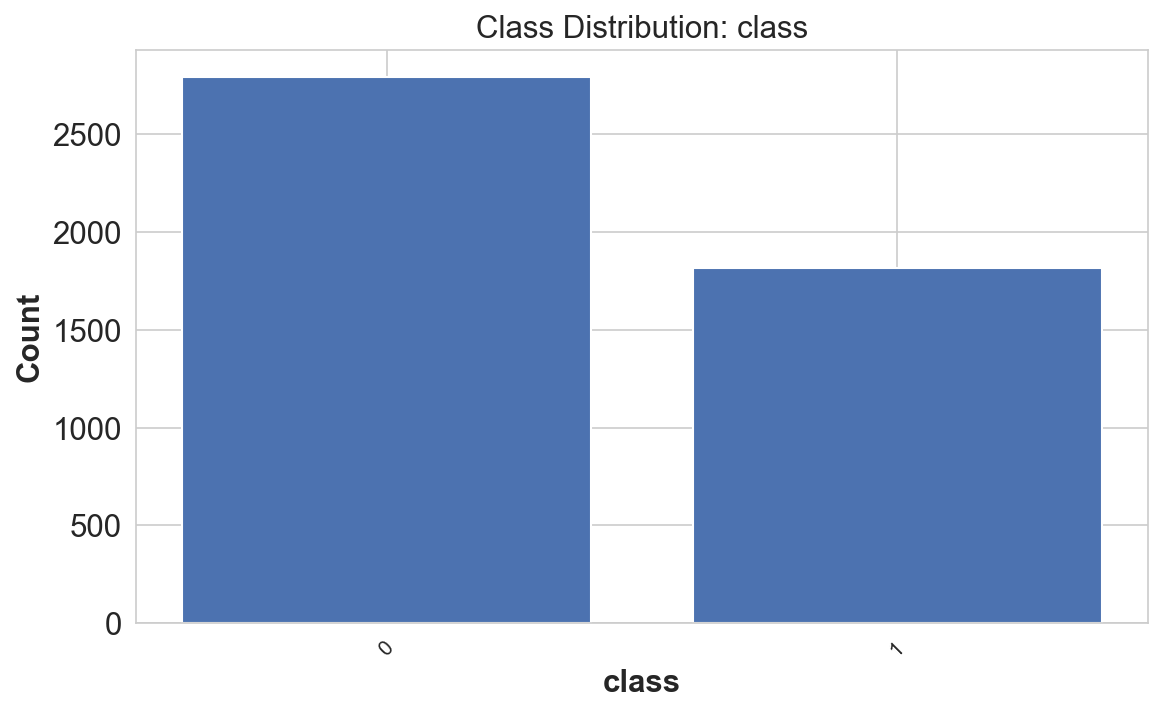

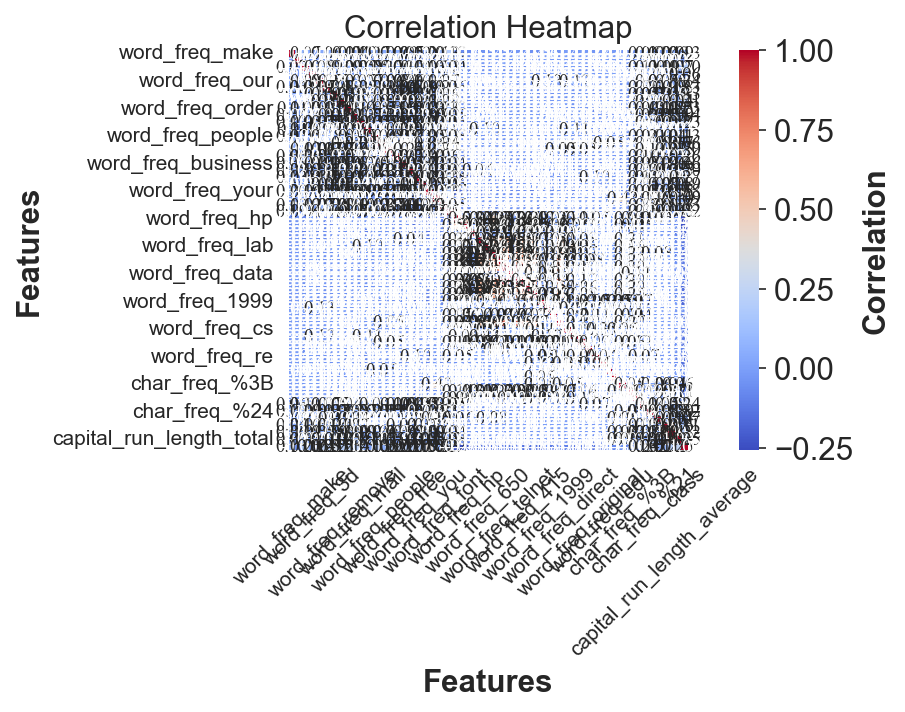

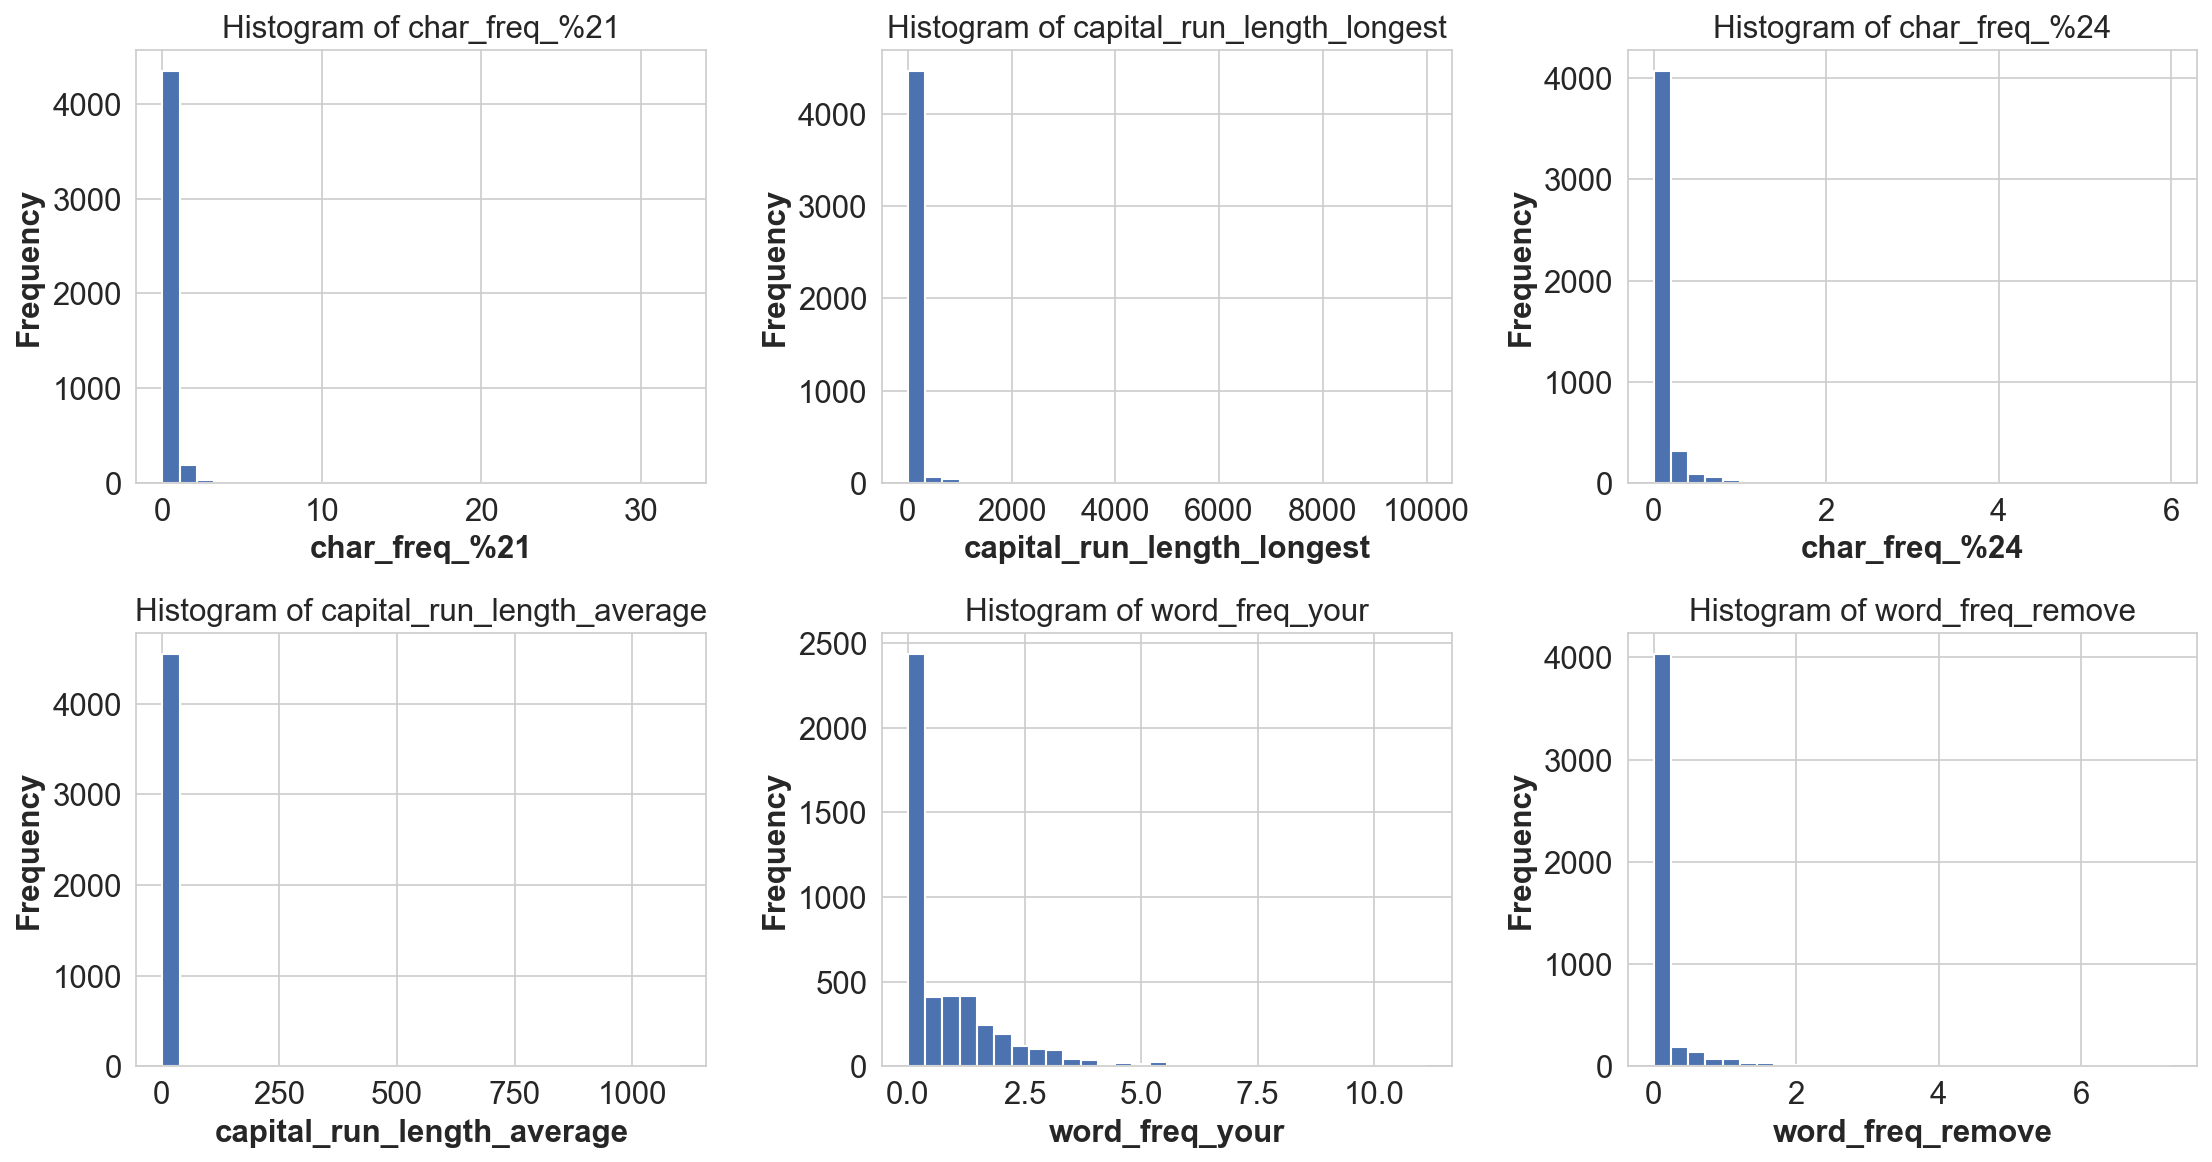

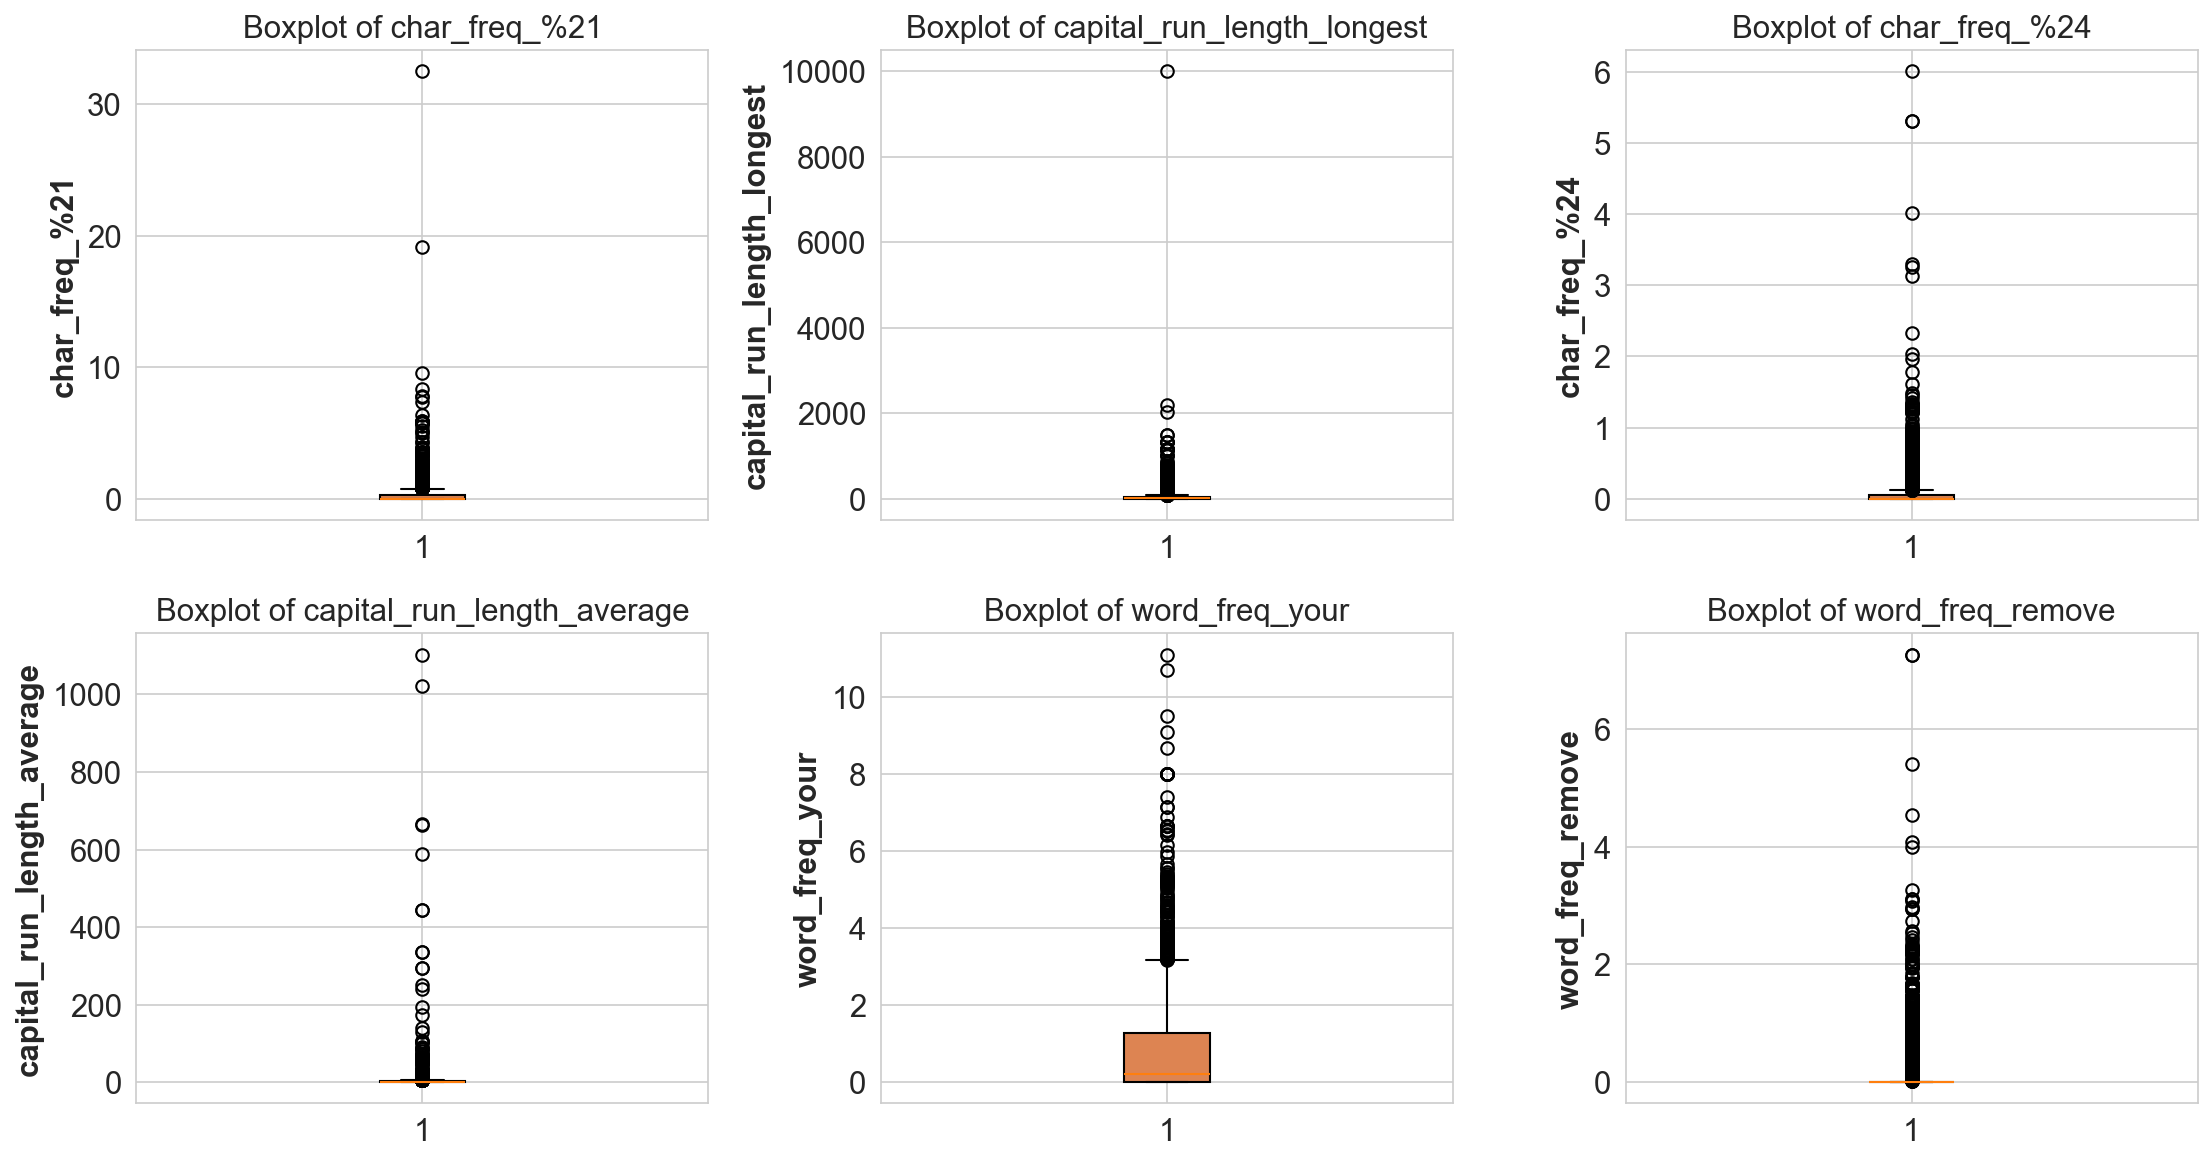

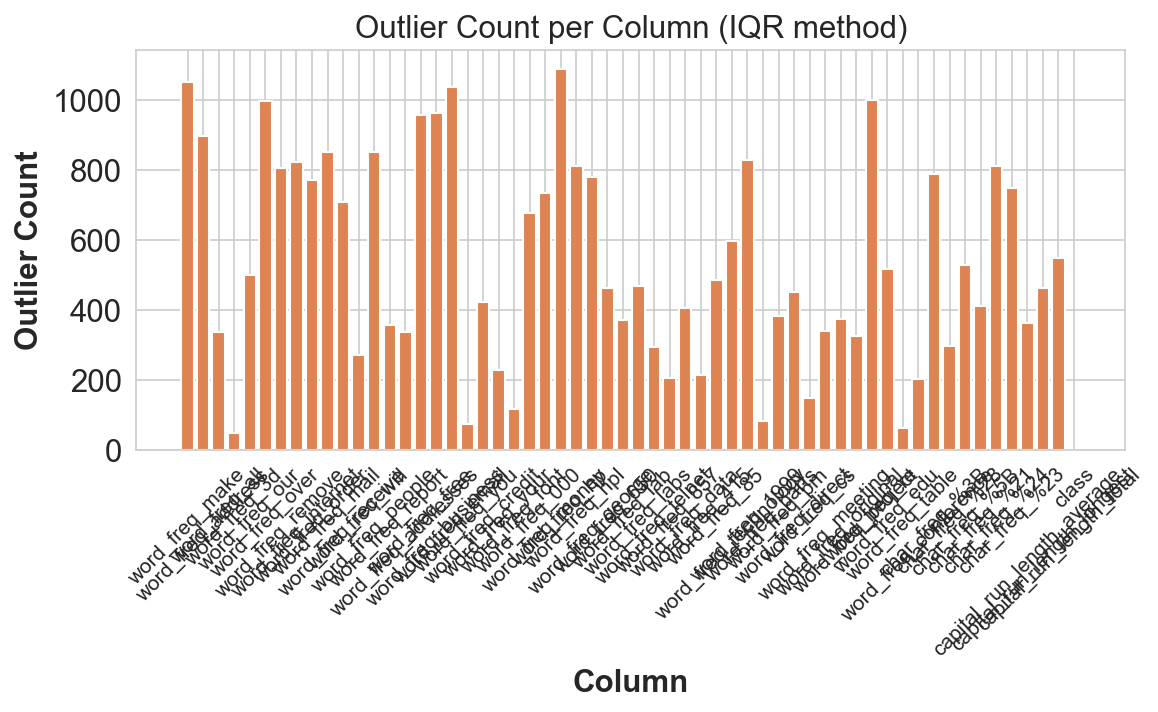

plotBargraph: no categorical columns, skipped


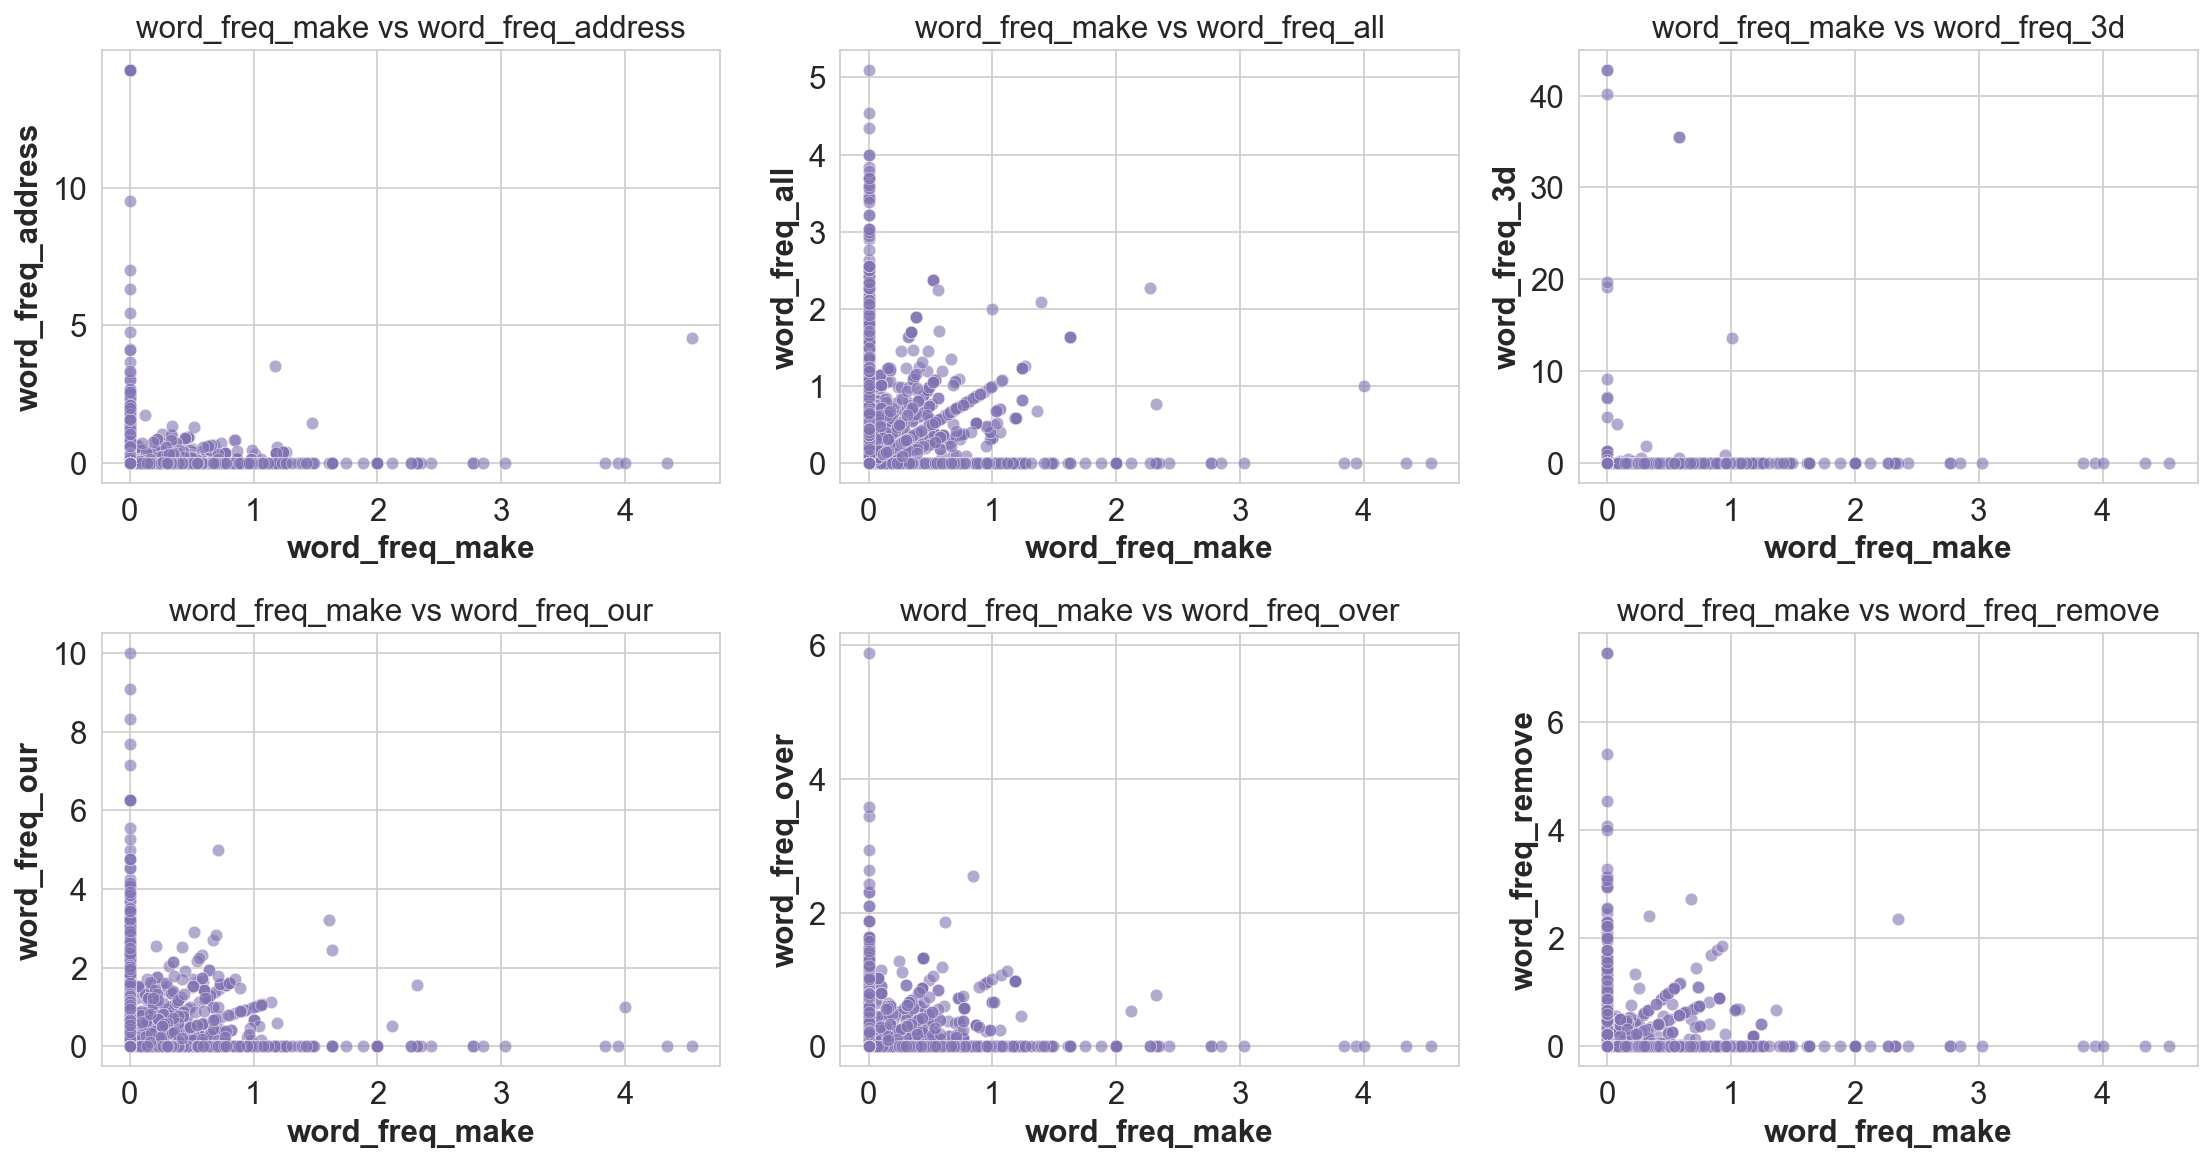

In [2]:
df=pd.read_csv("archive/spambase_csv.csv")
result=edaSummary(df,target="class",full=True)

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric = df.select_dtypes(include=['number']).columns
df[numeric] = scaler.fit_transform(df[numeric])

In [4]:
from sklearn.model_selection import train_test_split

X=df.drop(columns="class")
y=df["class"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay,roc_curve,precision_recall_curve,auc
from sklearn.preprocessing import label_binarize

fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

singlesize=(8,5)

def setGraphStyle():
    sns.set_style('whitegrid')
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150

def evaluateModel(model,X_train,X_test,y_train,y_test,name="Model"):
    start=time.perf_counter()
    model.fit(X_train,y_train)
    train_time=time.perf_counter()-start
    start=time.perf_counter()
    y_pred=model.predict(X_test)
    pred_time=time.perf_counter()-start
    metrics={"Model":name,"Accuracy":accuracy_score(y_test,y_pred),"Precision":precision_score(y_test,y_pred,average='weighted',zero_division=0),"Recall":recall_score(y_test,y_pred,average='weighted',zero_division=0),"F1 Score":f1_score(y_test,y_pred,average='weighted',zero_division=0),"Training Time":train_time,"Prediction Time":pred_time}
    y_prob=None
    if hasattr(model,"predict_proba"):
        y_prob=model.predict_proba(X_test)
        try:
            if pd.Series(y_test).nunique()==2:
                metrics["ROC-AUC"]=roc_auc_score(y_test,y_prob[:,1])
            else:
                metrics["ROC-AUC"]=roc_auc_score(y_test,y_prob,multi_class="ovr",average="weighted")
        except Exception:
            metrics["ROC-AUC"]=None
    metrics["Confusion Matrix"]=confusion_matrix(y_test,y_pred)
    return metrics,y_pred,y_prob

def runModels(models,X_train,X_test,y_train,y_test):
    results={}
    trained_models={}
    for name,model in models.items():
        metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name)
        results[name]=metrics
        trained_models[name]=model
    return pd.DataFrame(results).T,trained_models

def printMetrics(metrics):
    print("Accuracy :",metrics["Accuracy"])
    print("Precision :",metrics["Precision"])
    print("Recall :",metrics["Recall"])
    print("F1 Score :",metrics["F1 Score"])
    print("Training Time :",metrics["Training Time"])
    print("Prediction Time :",metrics["Prediction Time"])

def plotConfusionMatrices(trained_models,X_test,y_test):
    setGraphStyle()
    for name,model in trained_models.items():
        y_pred=model.predict(X_test)
        cm=confusion_matrix(y_test,y_pred)
        fig,ax=plt.subplots(figsize=singlesize)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues",ax=ax)
        ax.set_title(f"Confusion Matrix - {name}")
        plt.show()
        plt.close(fig)

def plotROCCurves(trained_models,X_test,y_test):
    setGraphStyle()
    classes=sorted(pd.Series(y_test).unique())
    fig,ax=plt.subplots(figsize=singlesize)
    if len(classes)==2:
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)[:,1]
            fpr,tpr,_=roc_curve(y_test,y_prob)
            ax.plot(fpr,tpr,label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    else:
        y_bin=label_binarize(y_test,classes=classes)
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)
            fpr,tpr,_=roc_curve(y_bin.ravel(),y_prob.ravel())
            ax.plot(fpr,tpr,label=f"{name} (micro-avg AUC={auc(fpr,tpr):.3f})")
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()
    plt.show()
    plt.close(fig)

def plotPRCurves(trained_models,X_test,y_test):
    setGraphStyle()
    classes=sorted(pd.Series(y_test).unique())
    fig,ax=plt.subplots(figsize=singlesize)
    if len(classes)==2:
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)[:,1]
            precision,recall,_=precision_recall_curve(y_test,y_prob)
            ax.plot(recall,precision,label=name)
    else:
        y_bin=label_binarize(y_test,classes=classes)
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)
            precision,recall,_=precision_recall_curve(y_bin.ravel(),y_prob.ravel())
            ax.plot(recall,precision,label=f"{name} (micro-avg)")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision Recall Curve")
    ax.legend()
    plt.show()
    plt.close(fig)

def plotAccuracyVsK(results_KNN,title="Accuracy vs k"):
    setGraphStyle()
    k=list(results_KNN.keys())
    accuracy=[results_KNN[i]["Accuracy"] for i in k]
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(k,accuracy,marker='o')
    ax.set_xlabel("k")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True)
    plt.show()
    plt.close(fig)

def plotCVFolds(cv_df,title="Cross-Validation Accuracy"):
    setGraphStyle()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(cv_df['Fold'],cv_df['Train Accuracy'],marker='o',label='Train Accuracy')
    ax.plot(cv_df['Fold'],cv_df['Validation Accuracy'],marker='o',label='Validation Accuracy')
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.show()
    plt.close(fig)

def plotBarComparison(results_df,column,ylabel,title):
    setGraphStyle()
    names=list(results_df.index)
    values=results_df[column].tolist()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(names,values)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x',rotation=15,labelsize=10)
    plt.show()
    plt.close(fig)

def plotGridSearchHeatmap(grid,param_x,param_y,title="GridSearchCV Heatmap"):
    setGraphStyle()
    res=pd.DataFrame(grid.cv_results_)
    pivot=res.pivot_table(values='mean_test_score',index=f'param_{param_y}',columns=f'param_{param_x}',aggfunc='mean')
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(pivot,annot=True,fmt='.3f',cmap='viridis',ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.set_title(title)
    ax.set_xlabel(param_x)
    ax.set_ylabel(param_y)
    plt.show()
    plt.close(fig)

def plotRandomSearchDistribution(search,title="RandomizedSearchCV Score Distribution"):
    setGraphStyle()
    scores=search.cv_results_['mean_test_score']
    fig,ax=plt.subplots(figsize=singlesize)
    ax.hist(scores,bins=10,color='#4C72B0',edgecolor='white')
    ax.axvline(search.best_score_,color='red',linestyle='--',label=f'Best Score={search.best_score_:.3f}')
    ax.set_xlabel("Mean CV Accuracy")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend()
    plt.show()
    plt.close(fig)

                         Model  Accuracy Precision    Recall  F1 Score  \
Gaussian NB        Gaussian NB  0.825369  0.859015  0.825369  0.827178   
Multinomial NB  Multinomial NB  0.898349  0.903908  0.898349  0.896162   
Bernoulli NB      Bernoulli NB  0.883579  0.883229  0.883579  0.882929   

               Training Time Prediction Time   ROC-AUC  \
Gaussian NB         0.015972         0.00411  0.919611   
Multinomial NB      0.009395        0.003584  0.962204   
Bernoulli NB        0.011138        0.006474  0.947841   

                       Confusion Matrix  
Gaussian NB     [[519, 178], [23, 431]]  
Multinomial NB   [[679, 18], [99, 355]]  
Bernoulli NB     [[643, 54], [80, 374]]  


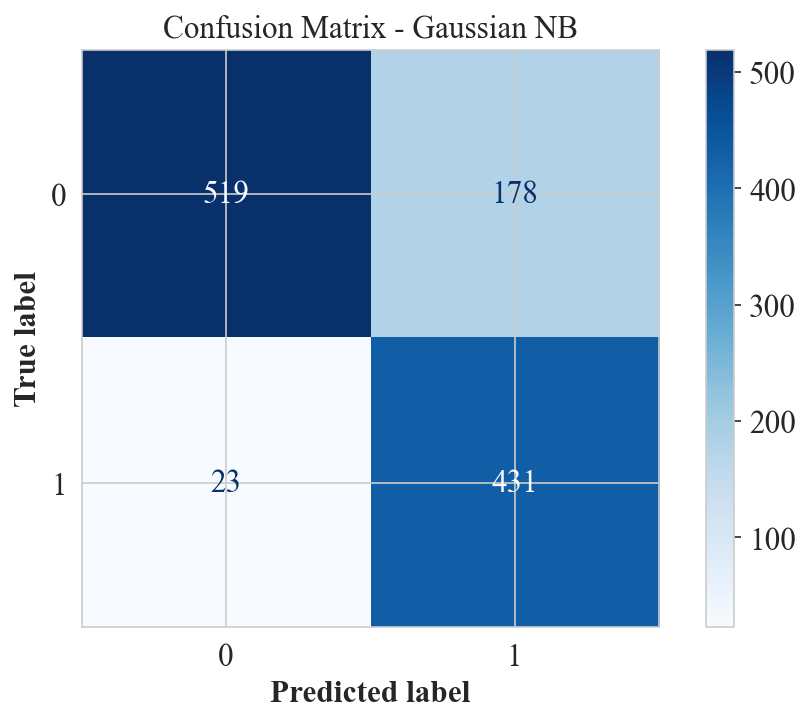

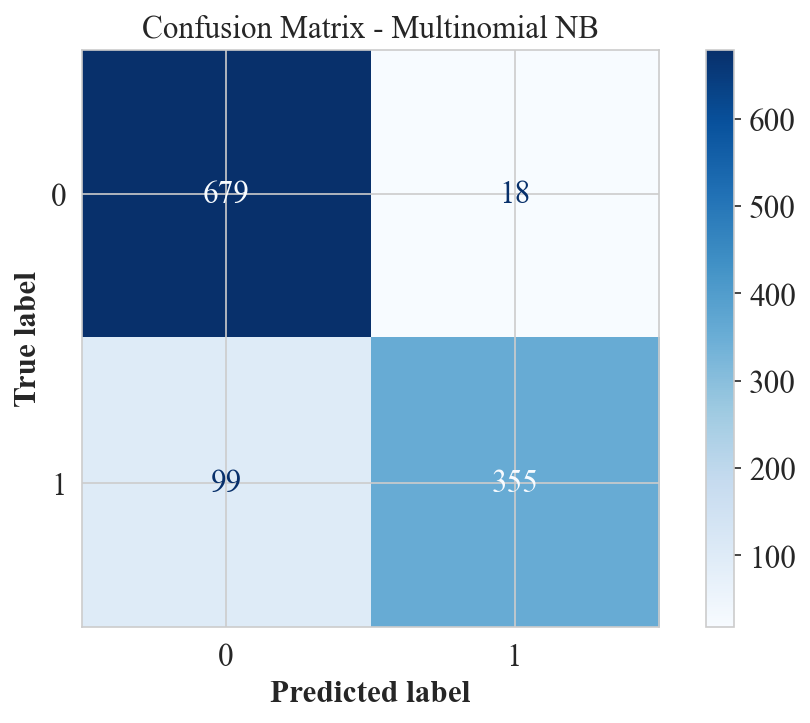

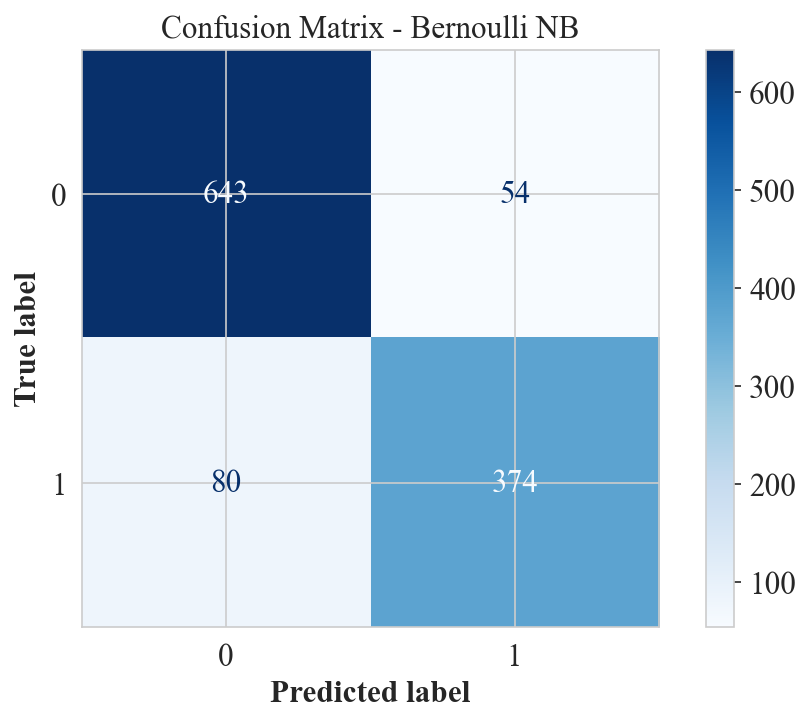

In [6]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
models={"Gaussian NB":GaussianNB(),"Multinomial NB":MultinomialNB(),"Bernoulli NB":BernoulliNB()}
results,trained_models=runModels(models,X_train,X_test,y_train,y_test)
print(results)
plotConfusionMatrices(trained_models,X_test,y_test)

   Model  Accuracy Precision    Recall  F1 Score Training Time  \
1    k=1  0.893136  0.893179  0.893136  0.893157      0.012303   
3    k=3  0.893136  0.892866  0.893136  0.892944      0.005687   
5    k=5  0.900956  0.900731  0.900956  0.900798      0.006749   
7    k=7  0.893136    0.8928  0.893136  0.892713      0.005463   
9    k=9  0.892268  0.892077  0.892268  0.891614       0.00669   
11  k=11  0.891399  0.891456  0.891399  0.890552      0.005666   

   Prediction Time   ROC-AUC        Confusion Matrix  
1         5.650789  0.888343  [[635, 62], [61, 393]]  
3         0.115467  0.932767  [[640, 57], [66, 388]]  
5         0.132519  0.943999  [[644, 53], [61, 393]]  
7         0.129206  0.949693  [[645, 52], [71, 383]]  
9         0.139653  0.951872  [[649, 48], [76, 378]]  
11        0.154189  0.954029  [[652, 45], [80, 374]]  


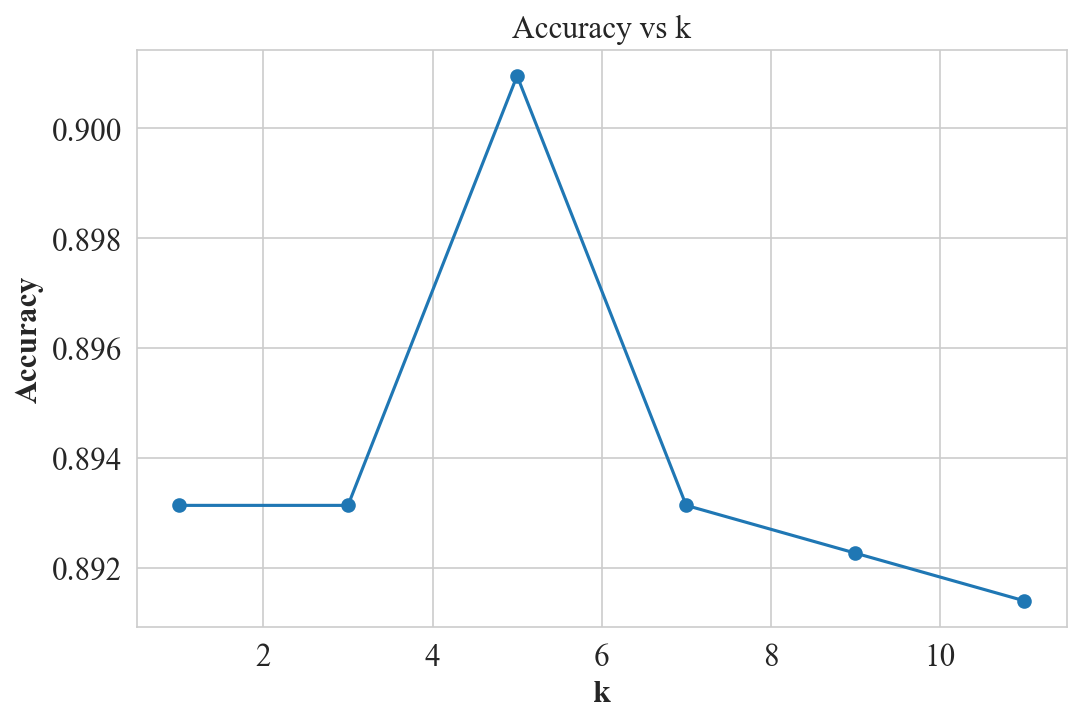

In [7]:
from sklearn.neighbors import KNeighborsClassifier

results_KNN={}
for i in range(1,12,2):
    model=KNeighborsClassifier(n_neighbors=i)
    metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name=f"k={i}")
    results_KNN[i]=metrics
print(pd.DataFrame(results_KNN).T)
plotAccuracyVsK(results_KNN)

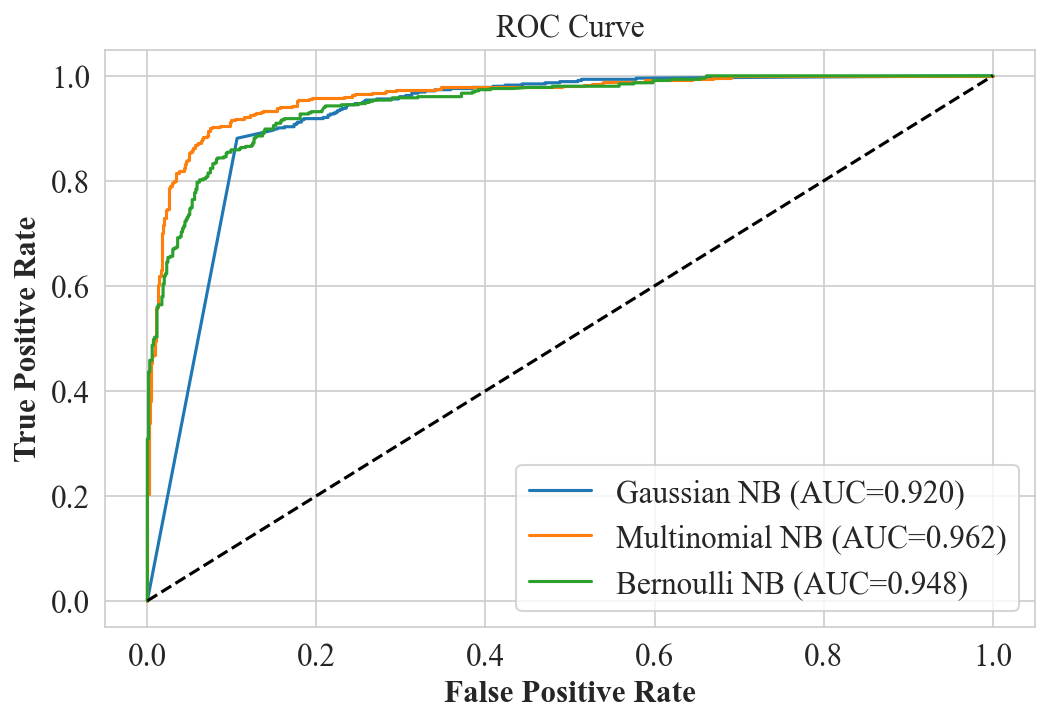

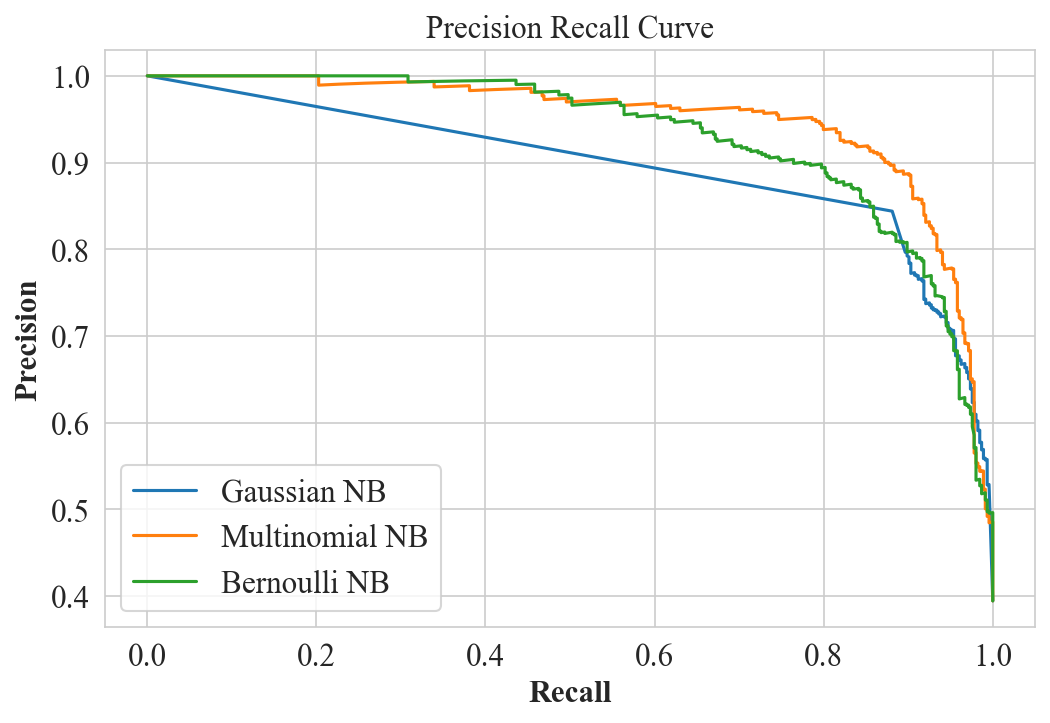

In [8]:
plotROCCurves(trained_models,X_test,y_test)
plotPRCurves(trained_models,X_test,y_test)

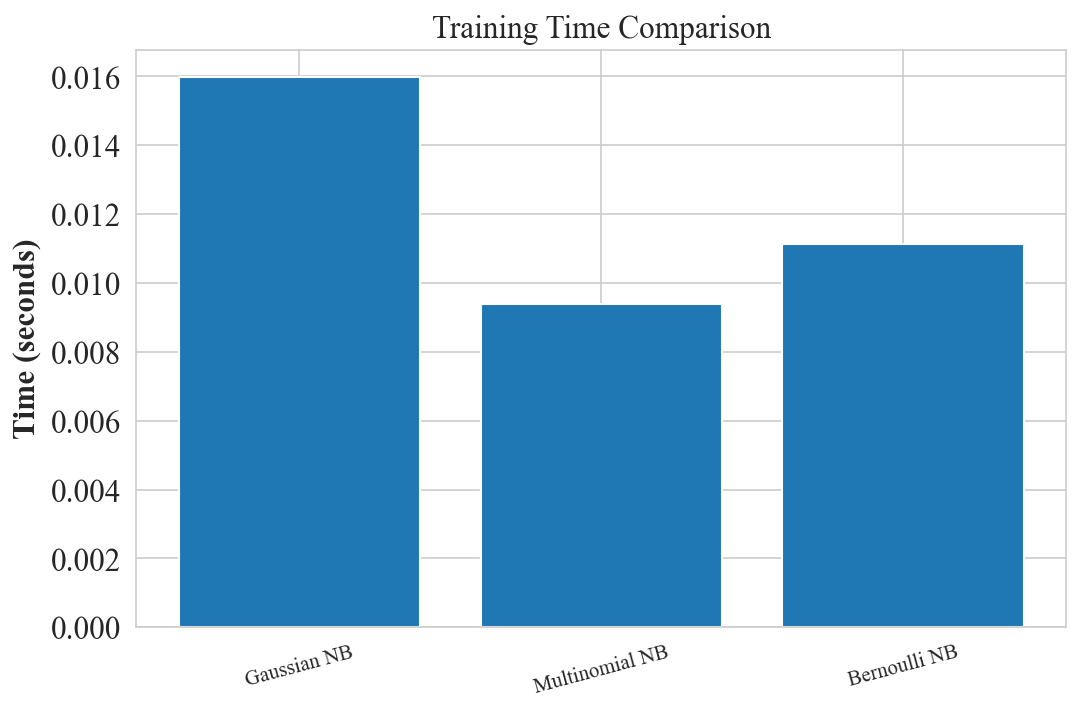

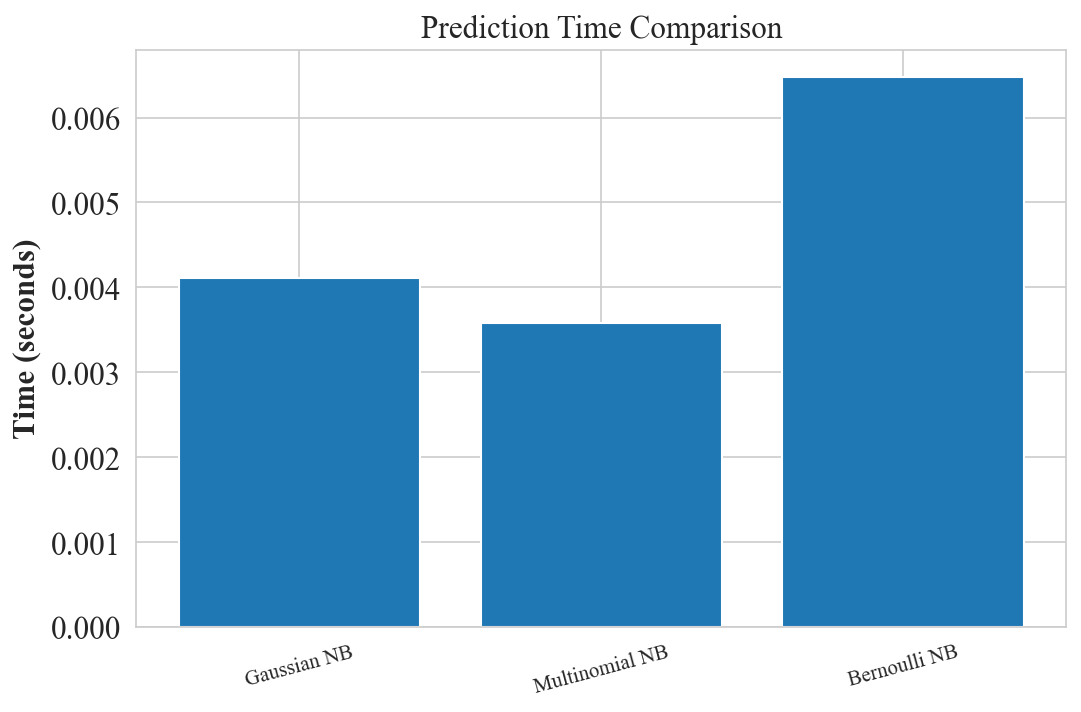

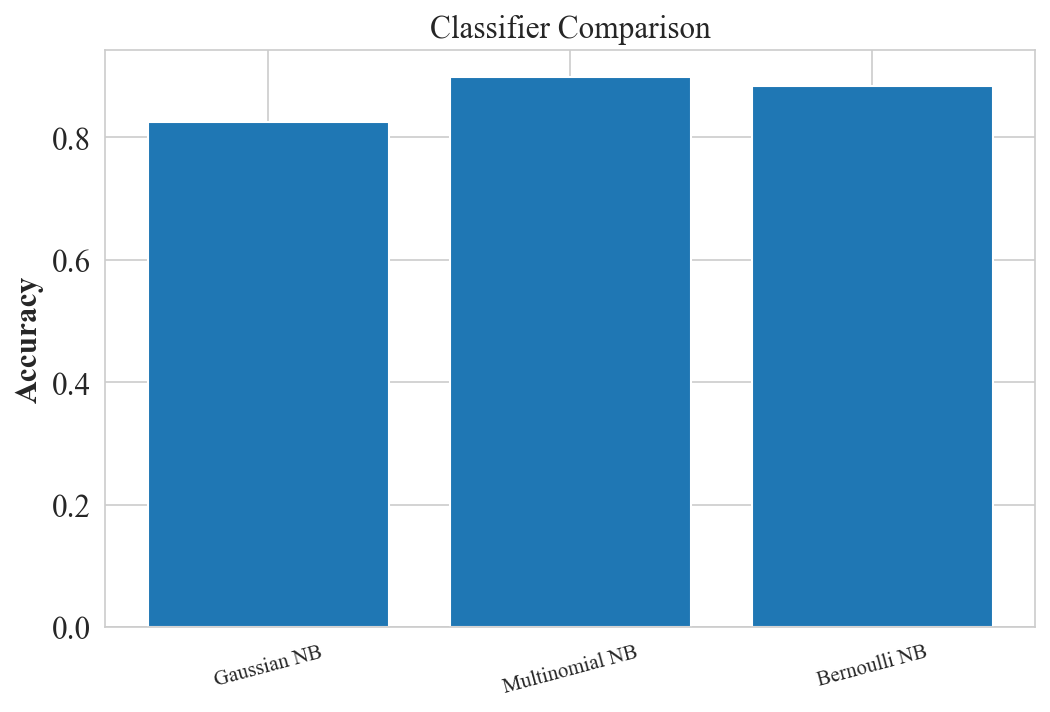

In [9]:
plotBarComparison(results,"Training Time","Time (seconds)","Training Time Comparison")
plotBarComparison(results,"Prediction Time","Time (seconds)","Prediction Time Comparison")
plotBarComparison(results,"Accuracy","Accuracy","Classifier Comparison")

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best Score: 0.9162318840579712


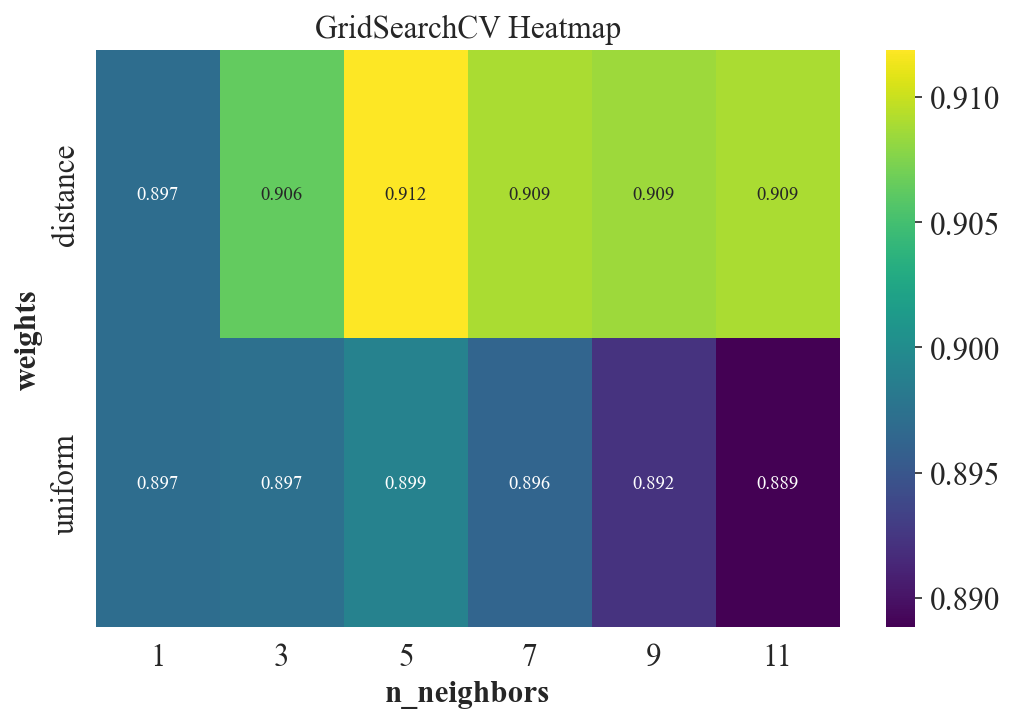

Accuracy : 0.9165942658557776
Precision : 0.9183663569585163
Recall : 0.9165942658557776
F1 Score : 0.9156080339394378
Training Time : 0.00791769998613745
Prediction Time : 0.22585280000930652


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn=KNeighborsClassifier()
param_grid={"n_neighbors":[1,3,5,7,9,11],"weights":["uniform","distance"],"metric":["euclidean","manhattan"]}
grid=GridSearchCV(estimator=knn,param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid.fit(X_train,y_train)
print("Best Parameters:",grid.best_params_)
print("Best Score:",grid.best_score_)
plotGridSearchHeatmap(grid,"n_neighbors","weights")
model=KNeighborsClassifier(**grid.best_params_)
metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name="GridSearch Best KNN")
printMetrics(metrics)

Best params: {'knn__weights': 'distance', 'knn__n_neighbors': 9, 'knn__metric': 'manhattan'}
Best CV accuracy: 0.9223
Test accuracy: 0.9253


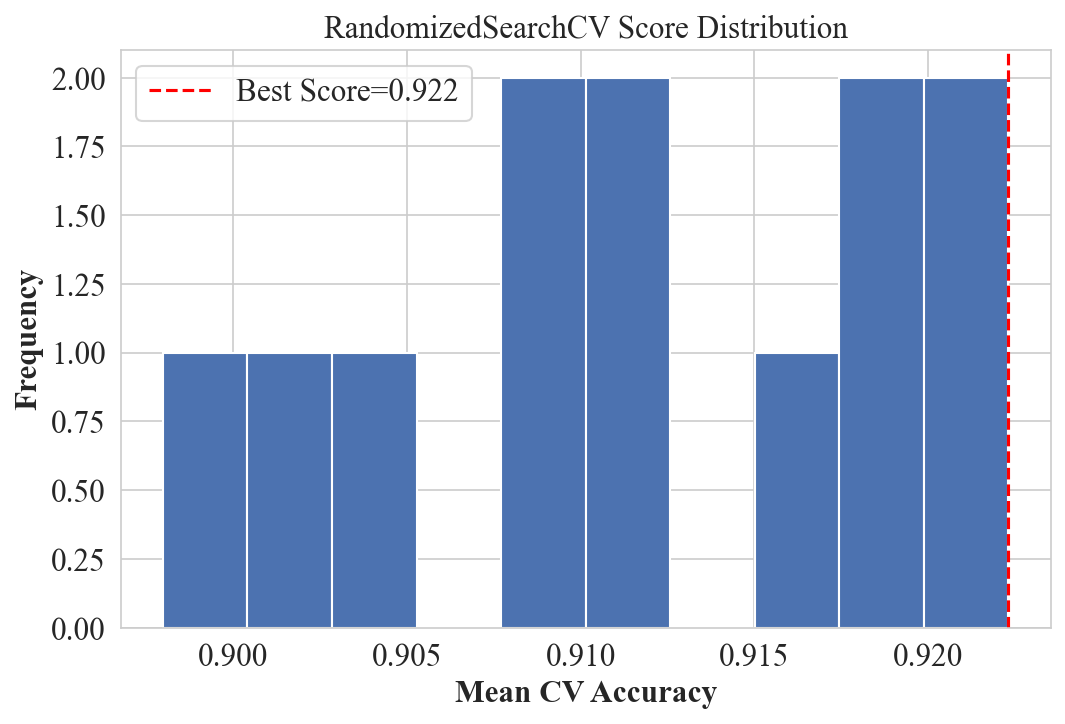

Accuracy : 0.9252823631624674
Precision : 0.9263223675739722
Recall : 0.9252823631624674
F1 Score : 0.9246028456122223
Training Time : 0.01903130003483966
Prediction Time : 0.25625229999423027


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe=Pipeline([('scaler',StandardScaler()),('knn',KNeighborsClassifier())])
param_dist={'knn__n_neighbors':[1,3,5,7,9,11],'knn__weights':['uniform','distance'],'knn__metric':['euclidean','manhattan','minkowski']}
search=RandomizedSearchCV(pipe,param_distributions=param_dist,n_iter=12,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
search.fit(X_train,y_train)
print('Best params:',search.best_params_)
print('Best CV accuracy:',round(search.best_score_,4))
print('Test accuracy:',round(search.score(X_test,y_test),4))
plotRandomSearchDistribution(search)
bestmodel=search.best_estimator_
metrics,y_pred,y_prob=evaluateModel(bestmodel,X_train,X_test,y_train,y_test,name="RandomSearch Best KNN")
printMetrics(metrics)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

print("KD Tree Metrics")
model=KNeighborsClassifier(n_neighbors=11,metric='manhattan',weights='distance',algorithm='kd_tree',leaf_size=30)
metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name="KD-Tree KNN")
printMetrics(metrics)

print("\nBall Tree Metrics")
model=KNeighborsClassifier(n_neighbors=9,metric='manhattan',weights='distance',algorithm='ball_tree',leaf_size=40)
metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name="Ball-Tree KNN")
printMetrics(metrics)

KD Tree Metrics
Accuracy : 0.9165942658557776
Precision : 0.9183663569585163
Recall : 0.9165942658557776
F1 Score : 0.9156080339394378
Training Time : 0.1304791999864392
Prediction Time : 0.8449076999677345

Ball Tree Metrics
Accuracy : 0.9174630755864466
Precision : 0.9184164990170085
Recall : 0.9174630755864466
F1 Score : 0.9166906093965158
Training Time : 0.05805420002434403
Prediction Time : 0.44744710001396015


   Fold  Train Accuracy  Validation Accuracy
0     1        0.811594             0.814493
1     2        0.816667             0.823188
2     3        0.813406             0.818841
3     4        0.822101             0.810145
4     5        0.822826             0.821739

Mean Validation Accuracy: 0.81768115942029


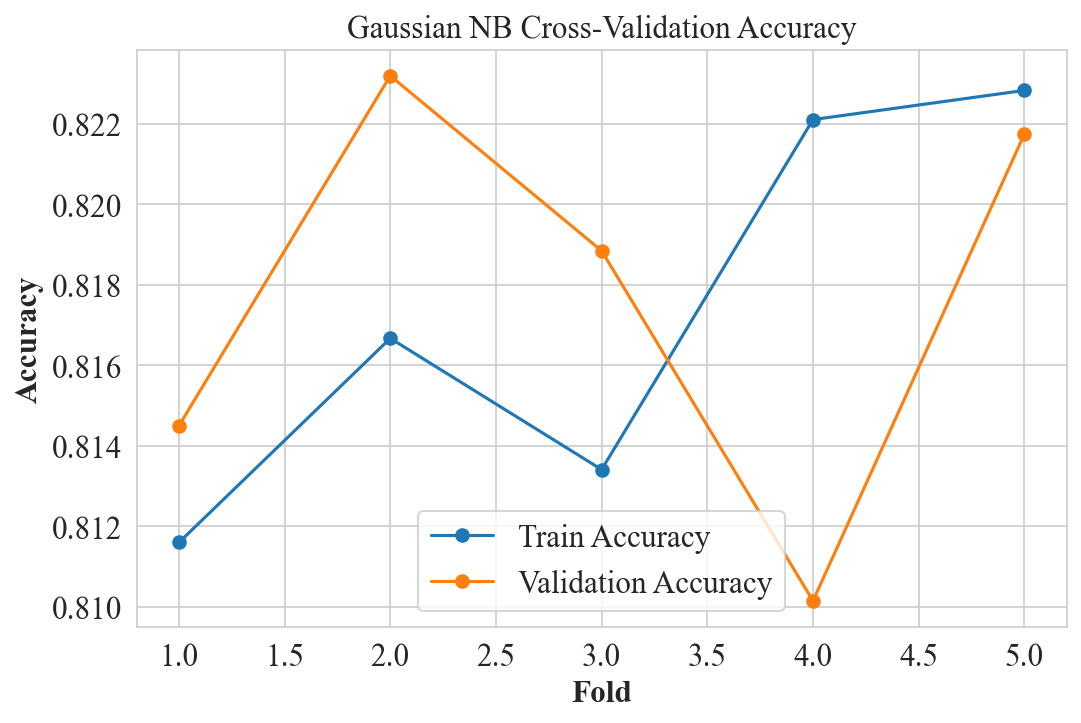

   Fold  Train Accuracy  Validation Accuracy
0     1        0.927536             0.895652
1     2        0.927536             0.900000
2     3        0.921377             0.908696
3     4        0.925725             0.881159
4     5        0.928623             0.891304

Mean Validation Accuracy: 0.8953623188405796


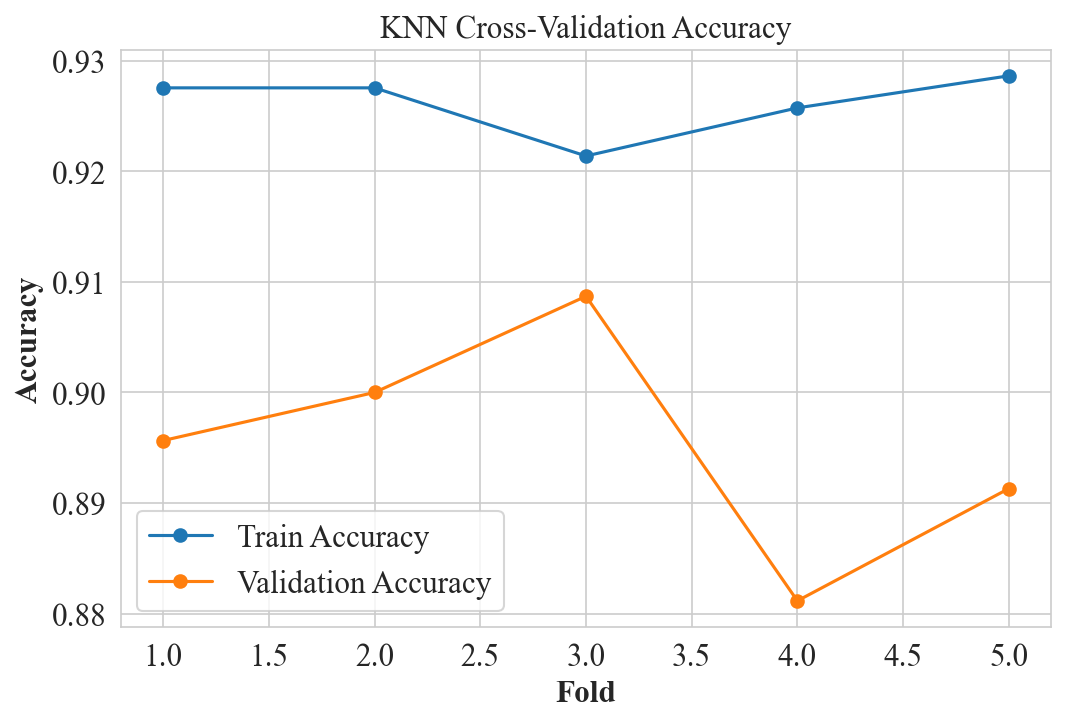

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold,cross_validate

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
gnb=GaussianNB()
cvresults=cross_validate(gnb,X_train,y_train,cv=cv,scoring='accuracy',return_train_score=True)
cvdf=pd.DataFrame({'Fold':[1,2,3,4,5],'Train Accuracy':cvresults['train_score'],'Validation Accuracy':cvresults['test_score']})
print(cvdf)
print("\nMean Validation Accuracy:",cvresults['test_score'].mean())
plotCVFolds(cvdf,title="Gaussian NB Cross-Validation Accuracy")
knn=KNeighborsClassifier(n_neighbors=5,algorithm='auto')
cvresults=cross_validate(knn,X_train,y_train,cv=cv,scoring='accuracy',return_train_score=True)
cvdf=pd.DataFrame({'Fold':[1,2,3,4,5],'Train Accuracy':cvresults['train_score'],'Validation Accuracy':cvresults['test_score']})
print(cvdf)
print("\nMean Validation Accuracy:",cvresults['test_score'].mean())
plotCVFolds(cvdf,title="KNN Cross-Validation Accuracy")